# Быстрое преобразование Фурье (FFT)

## Математическая идея

Дискретное преобразование Фурье задаётся формулой

$$
X_k = \sum_{n=0}^{N-1} x_n \exp\left(-j\frac{2\pi nk}{N}\right), \quad k = 0,1,\dots,N-1.
$$

Если длина сигнала равна `N = 2^p`, то последовательность удобно разбить на две части:

- чётные элементы: $x_n^{(1)} = x_{2n}$;
- нечётные элементы: $x_n^{(2)} = x_{2n+1}$.

После этого DFT длины `N` выражается через два DFT длины `N/2`:

$$
X_k = X_k^{(1)} + w_N^k X_k^{(2)}, \quad k = 0,\dots,\frac{N}{2}-1,
$$

$$
X_{k + N/2} = X_k^{(1)} - w_N^k X_k^{(2)}, \quad k = 0,\dots,\frac{N}{2}-1,
$$

где

$$
w_N = \exp\left(-j\frac{2\pi}{N}\right).
$$

Именно эта рекурсивная схема Cooley-Tukey и даёт быстрое преобразование Фурье со сложностью `O(N log N)` вместо `O(N^2)` у прямого DFT.


## Импорт библиотек и константы

Ниже задаются все параметры эксперимента без магических чисел: размеры сигналов для benchmark, параметры синусоид и число повторов измерения времени.


In [1]:
%matplotlib inline

from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np

# Настройка отображения графиков в ноутбуке.
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.unicode_minus"] = False

TWO_PI = 2.0 * np.pi
BENCHMARK_SIZES = (8, 16, 32, 64, 128, 256, 512, 1024)
DEMO_SIGNAL_LENGTH = 128
BENCHMARK_REPEATS = 3
RNG_SEED = 42

# Параметры тестового сигнала "сумма двух синусоид".
SINE_FREQ_1 = 5
SINE_FREQ_2 = 12
SINE_AMP_2 = 0.6
SINE_PHASE_2 = np.pi / 6.0

# Положение единичного импульса: N // IMPULSE_INDEX_DIVISOR.
IMPULSE_INDEX_DIVISOR = 8


## Вспомогательные функции и реализации DFT / FFT

Основная FFT реализована вручную. `np.fft` не используется.


In [2]:
def is_power_of_two(n: int) -> bool:
    """Проверяет, является ли положительное целое число степенью двойки."""

    return n > 0 and (n & (n - 1)) == 0


def as_complex_1d_array(x, name: str = "x") -> np.ndarray:
    """Преобразует вход к одномерному массиву complex128 и проверяет форму."""

    array = np.asarray(x)

    if array.ndim != 1:
        raise ValueError(f"{name} должен быть одномерной последовательностью.")
    if array.size == 0:
        raise ValueError(f"{name} не должен быть пустым.")

    return array.astype(np.complex128, copy=False)


def dft(x) -> np.ndarray:
    """Вычисляет прямое дискретное преобразование Фурье со сложностью O(N^2)."""

    signal = as_complex_1d_array(x, name="x")
    n_points = signal.size

    if not is_power_of_two(n_points):
        raise ValueError("Длина входа должна быть степенью двойки: N = 2^p.")

    spectrum = np.zeros(n_points, dtype=np.complex128)
    primitive_root = np.exp(-1j * TWO_PI / n_points)

    for k in range(n_points):
        # Для фиксированного k накапливаем сумму
        # X_k = sum(x_n * exp(-j * 2 * pi * n * k / N)).
        twiddle_k = primitive_root ** k
        current_factor = 1.0 + 0.0j
        current_sum = 0.0 + 0.0j

        for value in signal:
            current_sum += value * current_factor
            current_factor *= twiddle_k

        spectrum[k] = current_sum

    return spectrum


def _fft_recursive_impl(signal: np.ndarray) -> np.ndarray:
    """Внутренняя рекурсивная часть FFT без повторной проверки аргументов."""

    n_points = signal.size

    # Базовый случай: спектр сигнала длины 1 совпадает с самим сигналом.
    if n_points == 1:
        return signal.copy()

    # Рекурсивно считаем FFT для чётных и нечётных индексов.
    spectrum_even = _fft_recursive_impl(signal[::2])
    spectrum_odd = _fft_recursive_impl(signal[1::2])

    # Поворотные множители w_N^k.
    k = np.arange(n_points // 2, dtype=np.float64)
    twiddle = np.exp(-1j * TWO_PI * k / n_points)

    # Объединяем две половины по формулам Cooley-Tukey.
    first_half = spectrum_even + twiddle * spectrum_odd
    second_half = spectrum_even - twiddle * spectrum_odd
    return np.concatenate((first_half, second_half))


def fft_recursive(x) -> np.ndarray:
    """Вычисляет FFT по рекурсивной схеме Cooley-Tukey для N = 2^p."""

    signal = as_complex_1d_array(x, name="x")
    n_points = signal.size

    if not is_power_of_two(n_points):
        raise ValueError("FFT реализована только для длин N = 2^p.")

    return _fft_recursive_impl(signal)


def ifft(X) -> np.ndarray:
    """Вычисляет обратное преобразование Фурье через сопряжение и прямую FFT."""

    spectrum = as_complex_1d_array(X, name="X")
    n_points = spectrum.size

    if not is_power_of_two(n_points):
        raise ValueError("IFFT реализована только для длин N = 2^p.")

    # Используем стандартную формулу:
    # IFFT(X) = conj(FFT(conj(X))) / N.
    restored = fft_recursive(np.conjugate(spectrum))
    return np.conjugate(restored) / n_points


## Генерация тестовых сигналов, проверка точности и benchmark

Проверяем алгоритмы на четырёх типах сигналов:

1. сумма двух синусоид;
2. импульс;
3. случайный вещественный сигнал;
4. случайный комплексный сигнал.


In [3]:
def generate_test_signals(n_points: int, rng: np.random.Generator) -> dict[str, np.ndarray]:
    """Создаёт набор тестовых сигналов длины N = 2^p."""

    if not is_power_of_two(n_points):
        raise ValueError("Длина тестового сигнала должна быть степенью двойки.")

    n = np.arange(n_points, dtype=np.float64)
    impulse_index = n_points // IMPULSE_INDEX_DIVISOR

    # Сигнал из двух синусоид с разными частотами.
    sum_of_sines = np.sin(TWO_PI * SINE_FREQ_1 * n / n_points)
    sum_of_sines += SINE_AMP_2 * np.sin(TWO_PI * SINE_FREQ_2 * n / n_points + SINE_PHASE_2)

    # Единичный импульс в одной точке.
    impulse = np.zeros(n_points, dtype=np.float64)
    impulse[impulse_index] = 1.0

    # Случайные тестовые сигналы.
    random_real = rng.standard_normal(n_points)
    random_complex = rng.standard_normal(n_points) + 1j * rng.standard_normal(n_points)

    return {
        "Сумма двух синусоид": sum_of_sines,
        "Импульс": impulse,
        "Случайный вещественный": random_real,
        "Случайный комплексный": random_complex,
    }


def run_accuracy_tests(signals: dict[str, np.ndarray]):
    """Сравнивает DFT и FFT и оценивает ошибку восстановления сигнала."""

    results = []

    for name, signal in signals.items():
        signal_complex = as_complex_1d_array(signal, name=name)
        spectrum_dft = dft(signal_complex)
        spectrum_fft = fft_recursive(signal_complex)
        restored_signal = ifft(spectrum_fft)

        results.append(
            {
                "name": name,
                "N": signal_complex.size,
                "signal": signal_complex,
                "X_dft": spectrum_dft,
                "X_fft": spectrum_fft,
                "max_err": float(np.max(np.abs(spectrum_dft - spectrum_fft))),
                "reconstruction_err": float(np.max(np.abs(signal_complex - restored_signal))),
            }
        )

    return results


def measure_runtime(function, signal: np.ndarray, repeats: int = BENCHMARK_REPEATS) -> float:
    """Измеряет минимальное время выполнения функции на нескольких повторах."""

    timings = []
    for _ in range(repeats):
        start = perf_counter()
        function(signal)
        timings.append(perf_counter() - start)

    # Берём минимум, чтобы снизить влияние случайных всплесков времени.
    return min(timings)


def benchmark_algorithms(sizes, rng: np.random.Generator, repeats: int = BENCHMARK_REPEATS):
    """Сравнивает время работы DFT и FFT на наборе размеров N = 2^p."""

    benchmark_rows = []

    for n_points in sizes:
        signal = rng.standard_normal(n_points)
        time_dft = measure_runtime(dft, signal, repeats=repeats)
        time_fft = measure_runtime(fft_recursive, signal, repeats=repeats)
        speedup = time_dft / time_fft if time_fft > 0.0 else np.inf

        benchmark_rows.append(
            {
                "N": n_points,
                "time_dft": time_dft,
                "time_fft": time_fft,
                "speedup": speedup,
            }
        )

    return benchmark_rows


def print_accuracy_report(results) -> None:
    """Печатает таблицу ошибок для тестовых сигналов."""

    print("=== Проверка корректности на тестовых сигналах ===")
    print(f"{'Сигнал':<28} {'N':>5} {'max|DFT-FFT|':>18} {'max|x-IFFT(FFT)|':>20}")
    print("-" * 75)
    for row in results:
        print(
            f"{row['name']:<28} "
            f"{row['N']:>5d} "
            f"{row['max_err']:>18.6e} "
            f"{row['reconstruction_err']:>20.6e}"
        )


def print_benchmark_table(rows) -> None:
    """Печатает таблицу времени работы DFT и FFT."""

    print("\n=== Сравнение времени работы DFT и FFT ===")
    print(f"{'N':>6} {'time_dft, c':>14} {'time_fft, c':>14} {'speedup':>12}")
    print("-" * 52)
    for row in rows:
        print(
            f"{row['N']:>6d} "
            f"{row['time_dft']:>14.6e} "
            f"{row['time_fft']:>14.6e} "
            f"{row['speedup']:>12.2f}"
        )


def build_conclusion(rows) -> str:
    """Формирует краткий вывод по результатам benchmark."""

    first_row = rows[0]
    last_row = rows[-1]
    best_speedup = max(float(row["speedup"]) for row in rows)
    faster_rows = [row for row in rows if float(row["speedup"]) > 1.0]

    if faster_rows:
        threshold_n = int(faster_rows[0]["N"])
        threshold_text = f"Начиная примерно с N = {threshold_n}, FFT уже работает быстрее DFT. "
    else:
        threshold_text = "В данном запуске FFT не успела обогнать DFT на выбранных размерах. "

    return (
        "Вывод: на очень малых размерах накладные расходы рекурсии могут скрывать преимущество FFT, "
        "но при росте N выигрыш становится заметным. "
        + threshold_text
        + f"Для N = {int(first_row['N'])} отношение time_dft / time_fft равно {float(first_row['speedup']):.2f}, "
        f"а для N = {int(last_row['N'])} — уже {float(last_row['speedup']):.2f}. "
        f"Максимальное зафиксированное ускорение в этом запуске: {best_speedup:.2f}x."
    )


## Визуализация результатов

Строятся два типа графиков:

- исходный сигнал и модуль спектра для каждого тестового примера;
- зависимость времени работы DFT и FFT от размера сигнала.


In [6]:
def plot_signals_and_spectra(results) -> None:
    """Строит исходные сигналы и модули их спектров."""

    n_rows = len(results)
    figure, axes = plt.subplots(n_rows, 2, figsize=(13, 3.4 * n_rows), constrained_layout=True)

    if n_rows == 1:
        axes = np.array([axes])

    for row_index, row in enumerate(results):
        signal = row["signal"]
        spectrum = row["X_fft"]
        n = np.arange(signal.size)
        k = np.arange(spectrum.size)

        ax_signal = axes[row_index, 0]
        ax_spectrum = axes[row_index, 1]

        # Для комплексного сигнала отдельно показываем действительную и мнимую части.
        if np.max(np.abs(signal.imag)) > 1e-12:
            ax_signal.plot(n, signal.real, label="Re{x[n]}", linewidth=1.5)
            ax_signal.plot(n, signal.imag, label="Im{x[n]}", linewidth=1.2, linestyle="--")
        else:
            ax_signal.plot(n, signal.real, label="x[n]", linewidth=1.5)

        ax_signal.set_title(f"{row['name']}: исходный сигнал")
        ax_signal.set_xlabel("n")
        ax_signal.set_ylabel("Амплитуда")
        ax_signal.legend()
        ax_signal.grid(True, alpha=0.3)

        ax_spectrum.plot(k, np.abs(spectrum), color="tab:red", linewidth=1.5)
        ax_spectrum.set_title(f"{row['name']}: |X[k]|")
        ax_spectrum.set_xlabel("k")
        ax_spectrum.set_ylabel("Модуль спектра")
        ax_spectrum.grid(True, alpha=0.3)

    plt.show()


def plot_benchmark(rows) -> None:
    """Строит график сравнения времени работы DFT и FFT."""

    sizes = [int(row["N"]) for row in rows]
    dft_times = [float(row["time_dft"]) for row in rows]
    fft_times = [float(row["time_fft"]) for row in rows]

    figure, axis = plt.subplots(figsize=(10, 5.5), constrained_layout=True)
    axis.plot(sizes, dft_times, marker="o", linewidth=1.8, label="DFT, O(N^2)")
    axis.plot(sizes, fft_times, marker="s", linewidth=1.8, label="FFT, O(N log N)")
    axis.set_xscale("log", base=2)
    axis.set_yscale("log")
    axis.set_xticks(sizes)
    axis.set_xlabel("Размер сигнала N")
    axis.set_ylabel("Время, с")
    axis.set_title("Сравнение времени работы DFT и FFT")
    axis.grid(True, which="both", alpha=0.3)
    axis.legend()
    plt.show()


## Запуск полного решения

Эта ячейка:

1. генерирует тестовые сигналы;
2. считает DFT и FFT;
3. печатает таблицы ошибок и времени;
4. строит все требуемые графики;
5. выводит краткий итог.


Учебное задание: быстрое преобразование Фурье (FFT)
Демонстрационная длина сигнала: N = 128
Размеры для benchmark: (8, 16, 32, 64, 128, 256, 512, 1024)
Число повторов для измерения времени: 3

Сгенерировано 4 тестовых сигналов.

=== Проверка корректности на тестовых сигналах ===
Сигнал                           N       max|DFT-FFT|     max|x-IFFT(FFT)|
---------------------------------------------------------------------------
Сумма двух синусоид            128       6.910362e-12         5.646402e-16
Импульс                        128       4.556313e-14         5.073268e-18
Случайный вещественный         128       3.193070e-12         5.783136e-16
Случайный комплексный          128       8.139375e-12         1.110223e-15

=== Сравнение времени работы DFT и FFT ===
     N    time_dft, c    time_fft, c      speedup
----------------------------------------------------
     8   6.290500e-05   1.475660e-04         0.43
    16   1.806170e-04   3.091420e-04         0.58
    32   6.132830e-04 

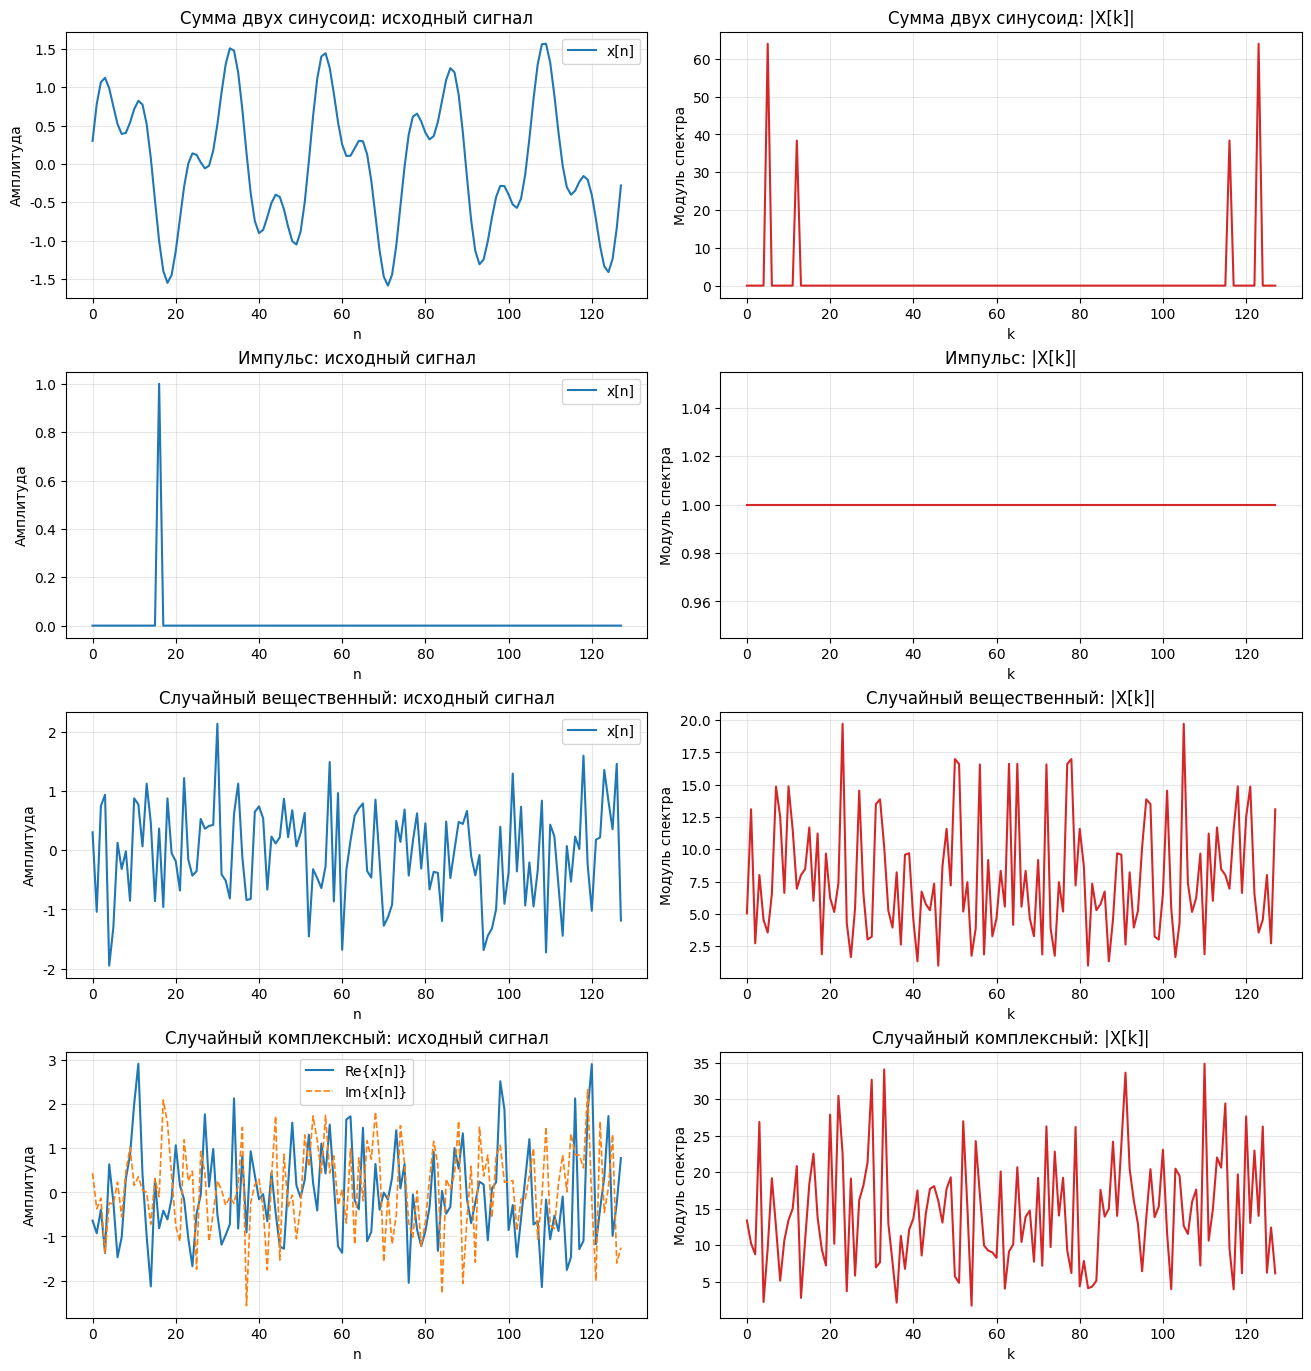

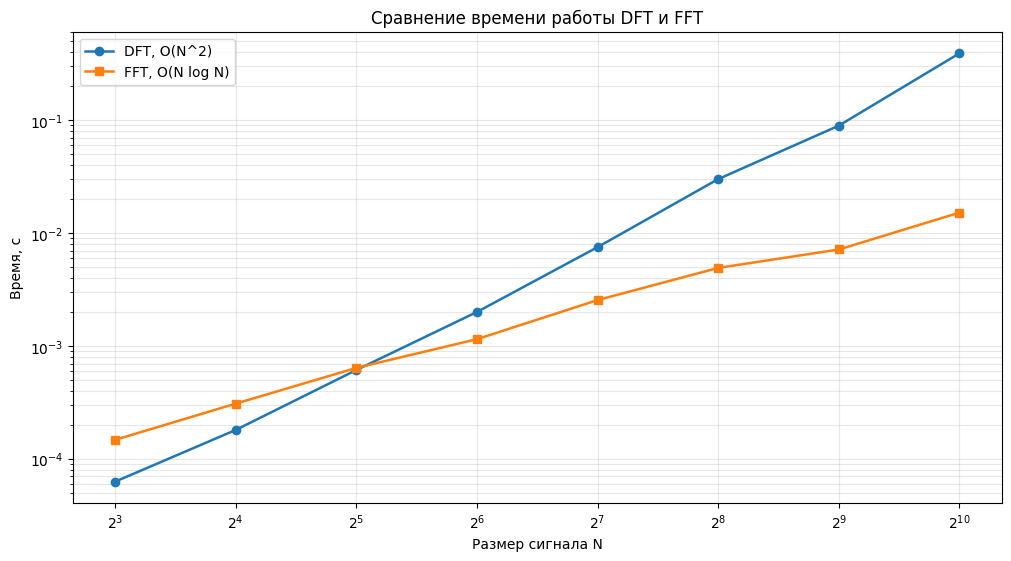

Вывод: на очень малых размерах накладные расходы рекурсии могут скрывать преимущество FFT, но при росте N выигрыш становится заметным. Начиная примерно с N = 64, FFT уже работает быстрее DFT. Для N = 8 отношение time_dft / time_fft равно 0.43, а для N = 1024 — уже 25.77. Максимальное зафиксированное ускорение в этом запуске: 25.77x.


In [5]:
def main() -> tuple[list[dict], list[dict]]:
    """Запускает все этапы решения и возвращает результаты для дальнейшего анализа."""

    rng_for_tests = np.random.default_rng(RNG_SEED)
    rng_for_benchmark = np.random.default_rng(RNG_SEED)

    print("Учебное задание: быстрое преобразование Фурье (FFT)")
    print(f"Демонстрационная длина сигнала: N = {DEMO_SIGNAL_LENGTH}")
    print(f"Размеры для benchmark: {BENCHMARK_SIZES}")
    print(f"Число повторов для измерения времени: {BENCHMARK_REPEATS}")

    test_signals = generate_test_signals(DEMO_SIGNAL_LENGTH, rng_for_tests)
    print(f"\nСгенерировано {len(test_signals)} тестовых сигналов.\n")

    accuracy_results = run_accuracy_tests(test_signals)
    print_accuracy_report(accuracy_results)

    benchmark_rows = benchmark_algorithms(
        BENCHMARK_SIZES,
        rng=rng_for_benchmark,
        repeats=BENCHMARK_REPEATS,
    )
    print_benchmark_table(benchmark_rows)

    print("\n=== Графики ===")
    plot_signals_and_spectra(accuracy_results)
    plot_benchmark(benchmark_rows)

    print(build_conclusion(benchmark_rows))
    return accuracy_results, benchmark_rows


accuracy_results, benchmark_rows = main()
